# Day 2 – NYC High School Directory Exploration

In this notebook, I explore the NYC High School Directory dataset using Python and pandas.  
The goal is to clean the data, filter schools in Brooklyn, answer exploratory questions, create summaries, and visualize the number of schools per borough.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

In [3]:
df = pd.read_csv("high-school-directory.csv")
df.head()

,dbn,school_name,borough,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,...,Council District,Census Tract,BIN,BBL,NTA,Zip Codes,Community Districts,Borough Boundaries,City Council Districts,Police Precincts
0,27Q260,Frederick Douglass Academy VI High School,Queens,Q465,718-471-2154,718-471-2890,9.0,12,NaN,NaN,...,31.0,100802.0,4300730.0,4.157360e+09,Far Rockaway-Bayswater ...,20529.0,51,3,47,59
1,21K559,Life Academy High School for Film and Music,Brooklyn,K400,718-333-7750,718-333-7775,9.0,12,NaN,NaN,...,47.0,306.0,3186454.0,3.068830e+09,Gravesend ...,17616.0,21,2,45,35
2,16K393,Frederick Douglass Academy IV Secondary School,Brooklyn,K026,718-574-2820,718-574-2821,9.0,12,NaN,NaN,...,36.0,291.0,3393805.0,3.016160e+09,Stuyvesant Heights ...,18181.0,69,2,49,52
3,08X305,Pablo Neruda Academy,Bronx,X450,718-824-1682,718-824-1663,9.0,12,NaN,NaN,...,18.0,16.0,2022205.0,2.036040e+09,Soundview-Castle Hill-Clason Point-Harding Par...,11611.0,58,5,31,26
4,03M485,Fiorello H. LaGuardia High School of Music & A...,Manhattan,M485,212-496-0700,212-724-5748,9.0,12,NaN,NaN,...,6.0,151.0,1030341.0,1.011560e+09,Lincoln Square ...,12420.0,20,4,19,12


## Preview of the dataset

First, I load the dataset and inspect the first few rows to understand its structure.

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (435, 69)

Columns:
['dbn', 'school_name', 'borough', 'building_code', 'phone_number', 'fax_number', 'grade_span_min', 'grade_span_max', 'expgrade_span_min', 'expgrade_span_max', 'bus', 'subway', 'primary_address_line_1', 'city', 'state_code', 'postcode', 'website', 'total_students', 'campus_name', 'school_type', 'overview_paragraph', 'program_highlights', 'language_classes', 'advancedplacement_courses', 'online_ap_courses', 'online_language_courses', 'extracurricular_activities', 'psal_sports_boys', 'psal_sports_girls', 'psal_sports_coed', 'school_sports', 'partner_cbo', 'partner_hospital', 'partner_highered', 'partner_cultural', 'partner_nonprofit', 'partner_corporate', 'partner_financial', 'partner_other', 'addtl_info1', 'addtl_info2', 'start_time', 'end_time', 'se_services', 'ell_programs', 'school_accessibility_description', 'number_programs', 'priority01', 'priority02', 'priority03', 'priority04', 'priority05', 'priority06', 'priority07', 'priority08', 'priority09', 'prior

## Clean column names

I clean the column names by:
- converting them to lowercase
- replacing spaces with underscores
- removing special characters

In [5]:
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(r"[^a-z0-9_]", "", regex=True)
)

df.columns.tolist()

['dbn',
 'school_name',
 'borough',
 'building_code',
 'phone_number',
 'fax_number',
 'grade_span_min',
 'grade_span_max',
 'expgrade_span_min',
 'expgrade_span_max',
 'bus',
 'subway',
 'primary_address_line_1',
 'city',
 'state_code',
 'postcode',
 'website',
 'total_students',
 'campus_name',
 'school_type',
 'overview_paragraph',
 'program_highlights',
 'language_classes',
 'advancedplacement_courses',
 'online_ap_courses',
 'online_language_courses',
 'extracurricular_activities',
 'psal_sports_boys',
 'psal_sports_girls',
 'psal_sports_coed',
 'school_sports',
 'partner_cbo',
 'partner_hospital',
 'partner_highered',
 'partner_cultural',
 'partner_nonprofit',
 'partner_corporate',
 'partner_financial',
 'partner_other',
 'addtl_info1',
 'addtl_info2',
 'start_time',
 'end_time',
 'se_services',
 'ell_programs',
 'school_accessibility_description',
 'number_programs',
 'priority01',
 'priority02',
 'priority03',
 'priority04',
 'priority05',
 'priority06',
 'priority07',
 'priori

In [6]:
df[["grade_span_min", "grade_span_max", "total_students"]].dtypes

,0
grade_span_min,float64
grade_span_max,int64
total_students,float64


In [7]:
df["grade_span_min"] = pd.to_numeric(df["grade_span_min"], errors="coerce")
df["grade_span_max"] = pd.to_numeric(df["grade_span_max"], errors="coerce")
df["total_students"] = pd.to_numeric(df["total_students"], errors="coerce")

## Filter schools in Brooklyn

Now I filter the dataset to include only schools located in Brooklyn.

In [8]:
brooklyn_df = df[df["borough"] == "Brooklyn"].copy()
brooklyn_df.head()

,dbn,school_name,borough,building_code,phone_number,fax_number,grade_span_min,grade_span_max,expgrade_span_min,expgrade_span_max,...,council_district,census_tract,bin,bbl,nta,zip_codes,community_districts,borough_boundaries,city_council_districts,police_precincts
1,21K559,Life Academy High School for Film and Music,Brooklyn,K400,718-333-7750,718-333-7775,9.0,12,NaN,NaN,...,47.0,306.0,3186454.0,3.068830e+09,Gravesend ...,17616.0,21,2,45,35
2,16K393,Frederick Douglass Academy IV Secondary School,Brooklyn,K026,718-574-2820,718-574-2821,9.0,12,NaN,NaN,...,36.0,291.0,3393805.0,3.016160e+09,Stuyvesant Heights ...,18181.0,69,2,49,52
7,17K122,Pathways in Technology Early College High Scho...,Brooklyn,K625,718-221-1593,718-221-1781,9.0,12,9.0,14.0,...,36.0,311.0,3030553.0,3.012160e+09,Crown Heights North ...,17615.0,16,2,49,49
10,23K644,Eagle Academy for Young Men II,Brooklyn,K271,718-495-0863,718-732-2129,6.0,12,NaN,NaN,...,41.0,301.0,3042157.0,3.015500e+09,Ocean Hill ...,13516.0,55,2,17,46
12,15K462,Secondary School for Law,Brooklyn,K460,718-832-4250,718-499-3947,9.0,12,NaN,NaN,...,39.0,155.0,3025510.0,3.010820e+09,Park Slope-Gowanus ...,17617.0,14,2,27,50


In [ ]:
## Question 1: How many total schools are in Brooklyn?

I use the unique school identifier column `dbn` to count unique schools.

In [9]:
brooklyn_school_count = brooklyn_df["dbn"].nunique()
brooklyn_school_count

121

In [10]:
print("Total unique schools in Brooklyn:", brooklyn_school_count)

Total unique schools in Brooklyn: 121


## Question 2: How many schools in Brooklyn offer Grade 9 entry?

To answer this correctly, I check whether Grade 9 falls within the school's grade range:
- `grade_span_min <= 9`
- `grade_span_max >= 9`

In [11]:
brooklyn_grade_9 = brooklyn_df[
    (brooklyn_df["grade_span_min"] <= 9) &
    (brooklyn_df["grade_span_max"] >= 9)
]

brooklyn_grade_9_count = brooklyn_grade_9["dbn"].nunique()
brooklyn_grade_9_count

121

In [12]:
print("Brooklyn schools offering Grade 9 entry:", brooklyn_grade_9_count)

Brooklyn schools offering Grade 9 entry: 121


## Count of schools per borough

I count unique schools per borough using the `dbn` column.

In [13]:
schools_per_borough = df.groupby("borough")["dbn"].nunique().sort_values(ascending=False)
schools_per_borough

,dbn
borough,
Brooklyn,121
Bronx,118
Manhattan,106
Queens,80
Staten Island,10


## Average number of students per borough

In [14]:
avg_students_per_borough = df.groupby("borough")["total_students"].mean().sort_values(ascending=False)
avg_students_per_borough

,total_students
borough,
Staten Island,1847.500000
Queens,1046.644737
Brooklyn,699.134454
Manhattan,589.825243
Bronx,490.406780


In [15]:
avg_students_per_borough.round(2)

,total_students
borough,
Staten Island,1847.50
Queens,1046.64
Brooklyn,699.13
Manhattan,589.83
Bronx,490.41


## Summary statistics of `grade_span_max` grouped by borough

In [16]:
grade_span_summary = df.groupby("borough")["grade_span_max"].describe()
grade_span_summary

,count,mean,std,min,25%,50%,75%,max
borough,,,,,,,,
Bronx,118.0,11.906780,0.369506,9.0,12.0,12.0,12.0,12.0
Brooklyn,121.0,11.933884,0.381566,9.0,12.0,12.0,12.0,12.0
Manhattan,106.0,11.877358,0.472135,9.0,12.0,12.0,12.0,12.0
Queens,80.0,11.825000,0.497462,10.0,12.0,12.0,12.0,12.0
Staten Island,10.0,12.000000,0.000000,12.0,12.0,12.0,12.0,12.0


## Bar chart: Number of schools per borough

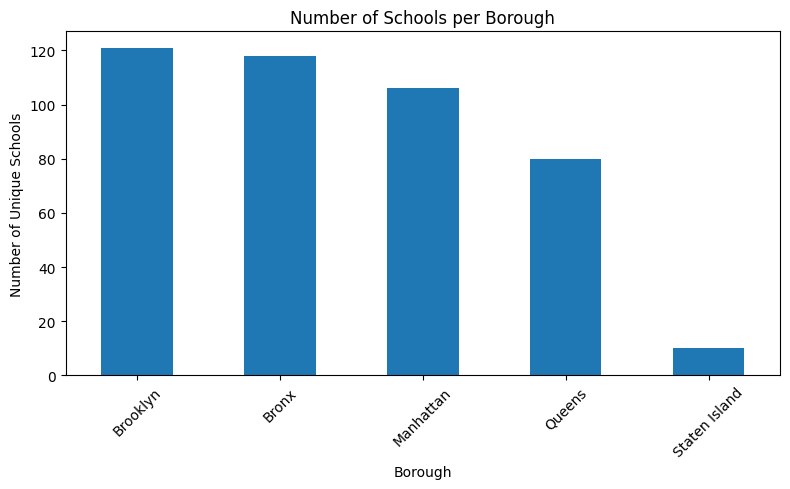

In [17]:
schools_per_borough.plot(kind="bar", figsize=(8, 5))
plt.title("Number of Schools per Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Unique Schools")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Insights

- Brooklyn has the highest number of unique high schools in the dataset, followed closely by the Bronx.
- All Brooklyn schools in this dataset appear to offer Grade 9 entry, based on the grade range provided.
- Staten Island has far fewer schools than the other boroughs, but its schools have the highest average number of students.

In [18]:
print("Total unique schools in Brooklyn:", brooklyn_school_count)
print("Brooklyn schools offering Grade 9 entry:", brooklyn_grade_9_count)
print("\nSchools per borough:")
print(schools_per_borough)
print("\nAverage students per borough:")
print(avg_students_per_borough.round(2))

Total unique schools in Brooklyn: 121
Brooklyn schools offering Grade 9 entry: 121

Schools per borough:
borough
Brooklyn         121
Bronx            118
Manhattan        106
Queens            80
Staten Island     10
Name: dbn, dtype: int64

Average students per borough:
borough
Staten Island    1847.50
Queens           1046.64
Brooklyn          699.13
Manhattan         589.83
Bronx             490.41
Name: total_students, dtype: float64
